 Loading Hugging Face ViT model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

 Using device: CPU
 Initializing GlassBox-ViT (PatchOcclusionExplainer)...
 Loading and resizing test image (Chelsea the cat)...
 Generating Patch Occlusion Explanation...


Patch Occlusion: 100%|██████████| 1/1 [00:11<00:00, 11.10s/it]


 EXPLANATION GENERATED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%


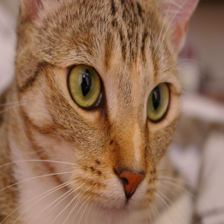

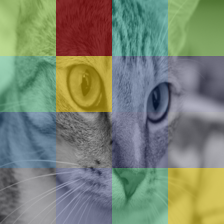

In [ ]:
import torch
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from skimage import data
from IPython.display import display

# Import your custom library
from glassbox_vit.patch_explainer import PatchOcclusionExplainer

# --- MODEL SETUP ---
print(" Loading Hugging Face ViT model...")
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)

# Set device automatically
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Using device: {device.upper()}")
model.to(device)
model.eval()

# Extract class names from the model config
class_names = list(model.config.id2label.values())

# --- PREDICTION FUNCTION WRAPPER ---
# This acts as the bridge between our black-box explainer and Hugging Face
def hf_prediction_function(images_numpy):
    imgs_pil = [Image.fromarray((img).astype('uint8')) for img in images_numpy]
    inputs = processor(images=imgs_pil, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    # Return softmax probabilities as a numpy array
    return torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()

# --- INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT (PatchOcclusionExplainer)...")
patch_explainer = PatchOcclusionExplainer(prediction_function=hf_prediction_function)

# --- LOAD TEST IMAGE ---
print(" Loading and resizing test image (Chelsea the cat)...")
# Using skimage's built-in image to avoid download issues
image_np = data.chelsea()
# ViT models expect 224x224 images
test_image = Image.fromarray(image_np).convert("RGB").resize((224, 224))

# --- GENERATE EXPLANATION ---
print(" Generating Patch Occlusion Explanation...")
# ViT-base uses 16x16 patches. We use mask_value=0 (black patches)
# show_progress=True will display a nice loading bar in the terminal
result = patch_explainer.generate(
    pil_image=test_image,
    patch_size=56,
    mask_value=0,
    batch_size=32,
    show_progress=True
)

# --- DISPLAY RESULTS ---

# Extract final prediction metrics
predicted_class = class_names[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n EXPLANATION GENERATED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")
display(test_image)
display(result['patch_image'])